# Queries

This notebook demonstrates query functions and batch parent fault selection. Topics covered:

1. Lookups and spatial queries — `get_parent_fault_id`, `get_nearest_subsection_index`, `get_subsections_list`, `get_parents_list`
2. `ParentSelection` — batch access to parent fault summaries, subsection attributes, and enriched ruptures

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from parserf.models import FaultModel, FaultModelDataset
from parserf.queries import (
    get_nearest_subsection_index,
    get_parents_list,
    get_subsections_list,
)
from parserf.selection import ParentSelection

In [2]:
ds = FaultModelDataset(FaultModel.NSHMP_2023)

## 1. Lookups and Spatial Queries

### get_parent_fault_id

Resolve a parent fault name to its integer ID.

In [3]:
pid = ds.get_parent_fault_id(name="Little Lake")
print("Parent ID for 'Little Lake':", pid)

Parent ID for 'Little Lake': 145


### get_nearest_subsection_index

Find the closest subsection to a geographic coordinate.

In [4]:
# Coordinate near Ridgecrest, CA
idx = get_nearest_subsection_index(ds, lat=35.77, lon=-117.60)
print("Nearest subsection index:", idx)
print("Name:", ds.subsections.loc[idx, "name"])

Nearest subsection index: 3276
Name: Paxton Ranch (4)


### get_subsections_list

Find all subsection indices within a search radius, sorted by distance.

In [5]:
nearby_subs = get_subsections_list(ds, lat=35.77, lon=-117.60, dist_km=50.0)
print(f"{len(nearby_subs)} subsections within 50 km")
print("First 10:", nearby_subs[:10])

90 subsections within 50 km
First 10: [3276, 3275, 3277, 3274, 16, 17, 3758, 18, 3759, 2446]


### get_parents_list

Find all parent fault IDs within a search radius, sorted by nearest child subsection.

In [6]:
parent_ids = get_parents_list(ds, lat=35.77, lon=-117.60, dist_km=50.0)
print(f"{len(parent_ids)} parent faults within 50 km")

# Look up names for the parent IDs
pid_to_name = ds.parent_ids.set_index("parent_id")["parent_name"]
for pid in parent_ids:
    print(f"  {pid}: {pid_to_name[pid]}")

14 parent faults within 50 km
  331: Paxton Ranch
  310: Airport Lake (south)
  338: Salt Wells Valley
  145: Little Lake
  1: Airport Lake
  278: Sierra Nevada (south)
  881: Garlock (center)
  287: Tank Canyon
  6: Ash Hill
  17: Blackwater
  272: Scodie Lineament (seismicity)
  204: Panamint Valley
  299: White Wolf (extension)
  89: Gravel Hills - Harper Lake


## 2. ParentSelection

`ParentSelection` takes the parent IDs from above and provides batch access to their
subsection attributes, parent summaries, and enriched ruptures using a single rupture
table scan.

In [7]:
sel = ParentSelection(ds, parent_ids)

### Parent Fault Summary

`.parents` returns a GeoDataFrame indexed by `parent_id` with `parent_name`, `style`
(dominant faulting style), and `geometry` (oriented surface trace). These are the
parent-level properties that cannot be derived from a single subsection row.

In [8]:
parents = sel.parents
print(f"{len(parents)} parent faults")
print("Columns:", list(parents.columns))
parents

14 parent faults
Columns: ['parent_name', 'style', 'geometry']


,parent_name,style,geometry
parent_id,,,
331,Paxton Ranch,normal oblique,"LINESTRING (-117.37007 35.57176, -117.39939 35..."
310,Airport Lake (south),normal,"LINESTRING (-117.68011 35.70441, -117.70079 35..."
338,Salt Wells Valley,strike-slip,"LINESTRING (-117.48631 35.71882, -117.51643 35..."
145,Little Lake,normal oblique,"LINESTRING (-117.64749 35.60516, -117.68458 35..."
1,Airport Lake,normal oblique,"LINESTRING (-117.74953 35.74054, -117.76365 35..."
278,Sierra Nevada (south),normal oblique,"LINESTRING (-118.023 35.2943, -118.04 35.347, ..."
881,Garlock (center),strike-slip,"LINESTRING (-118.02395 35.28346, -117.97208 35..."
287,Tank Canyon,strike-slip,"LINESTRING (-117.196 35.91796, -117.23292 35.8..."
6,Ash Hill,normal oblique,"LINESTRING (-117.4596 36.3944, -117.44121 36.3..."


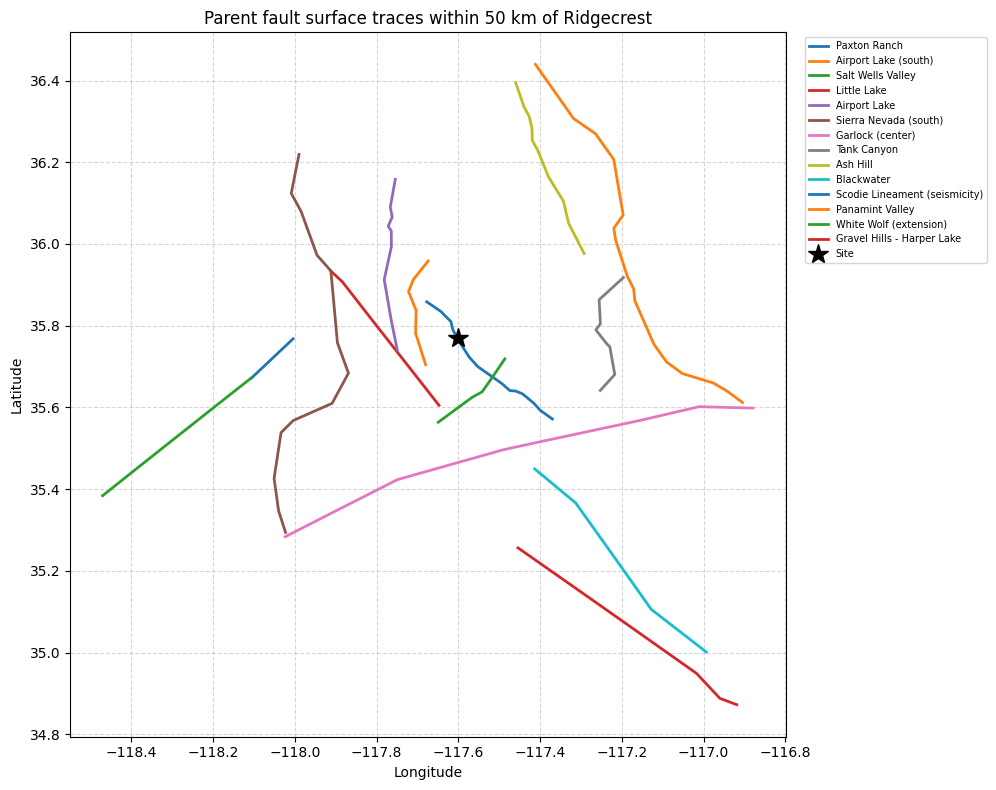

In [9]:
# Plot parent fault surface traces
fig, ax = plt.subplots(figsize=(10, 8))

for pid in sel.parent_ids:
    row = parents.loc[pid]
    xs, ys = row["geometry"].xy
    ax.plot(xs, ys, linewidth=2, label=row["parent_name"])

# Mark the site
ax.plot(-117.60, 35.77, "k*", markersize=15, zorder=5, label="Site")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Parent fault surface traces within 50 km of Ridgecrest")
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1))
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Subsections

`.subsections` returns all subsections for the selected parents (full extent — not filtered
by radius). Each row has `parent_id`, `dip`, `upper_depth_km`, `lower_depth_km`, `area_km2`,
`geometry`, etc. You can group by `parent_id` to compute your own aggregations (e.g.,
area-weighted dip).

In [10]:
subs = sel.subsections
print(f"{len(subs)} subsections across {subs['parent_id'].nunique()} parents")

# Example: compute area-weighted dip per parent
for pid in sel.parent_ids[:5]:
    group = subs[subs["parent_id"] == pid]
    weights = group["area_km2"]
    wtd_dip = np.average(group["dip"], weights=weights)
    name = parents.loc[pid, "parent_name"]
    print(f"  {name}: {len(group)} subsections, area-wtd dip = {wtd_dip:.1f}°")

127 subsections across 14 parents
  Paxton Ranch: 6 subsections, area-wtd dip = 90.0°
  Airport Lake (south): 4 subsections, area-wtd dip = 50.0°
  Salt Wells Valley: 4 subsections, area-wtd dip = 90.0°
  Little Lake: 7 subsections, area-wtd dip = 90.0°
  Airport Lake: 6 subsections, area-wtd dip = 50.0°


### Ruptures

`.ruptures` returns an enriched GeoDataFrame in exploded form: one row per (rupture, parent)
pair. Each row has `m` (magnitude), `rate`, `parent_id`, and `area_pct` (percentage of the
rupture's total area contributed by that parent). The DataFrame index identifies the original
rupture — duplicate index values indicate rows from the same rupture spanning multiple parents.

To get the parent-attributed rate, multiply `rate * area_pct / 100`.

In [11]:
rups = sel.ruptures
unique_ruptures = rups.index.nunique()
print(f"{len(rups)} rows ({unique_ruptures} unique ruptures x {len(sel.parent_ids)} max parents)")
print("Columns:", list(rups.columns))
rups[["m", "rate", "parent_id", "area_pct", "length_km", "area_km2"]].head(10)

318341 rows (48090 unique ruptures x 14 max parents)
Columns: ['m', 'rate', 'depth', 'dip', 'width', 'rake', 'geometry', 'length_km', 'area_km2', 'parent_id', 'area_pct']


,m,rate,parent_id,area_pct,length_km,area_km2
72,6.51,2.012449e-05,1,100.000000,15.706558,266.544916
73,6.69,4.383015e-05,1,100.000000,23.559808,399.816887
74,6.83,1.055954e-05,1,100.000000,31.412992,533.087726
75,6.94,5.157790e-06,1,100.000000,39.269534,666.415568
76,7.03,9.238737e-05,1,100.000000,47.122932,799.690047
77,6.74,0.000000e+00,1,62.145187,28.195931,428.906773
77,6.74,0.000000e+00,145,37.854813,28.195931,428.906773
78,6.82,1.640551e-06,1,52.255033,34.440386,510.084680
78,6.82,1.640551e-06,145,47.744967,34.440386,510.084680
79,7.02,6.849859e-07,1,34.908029,49.376996,763.563352


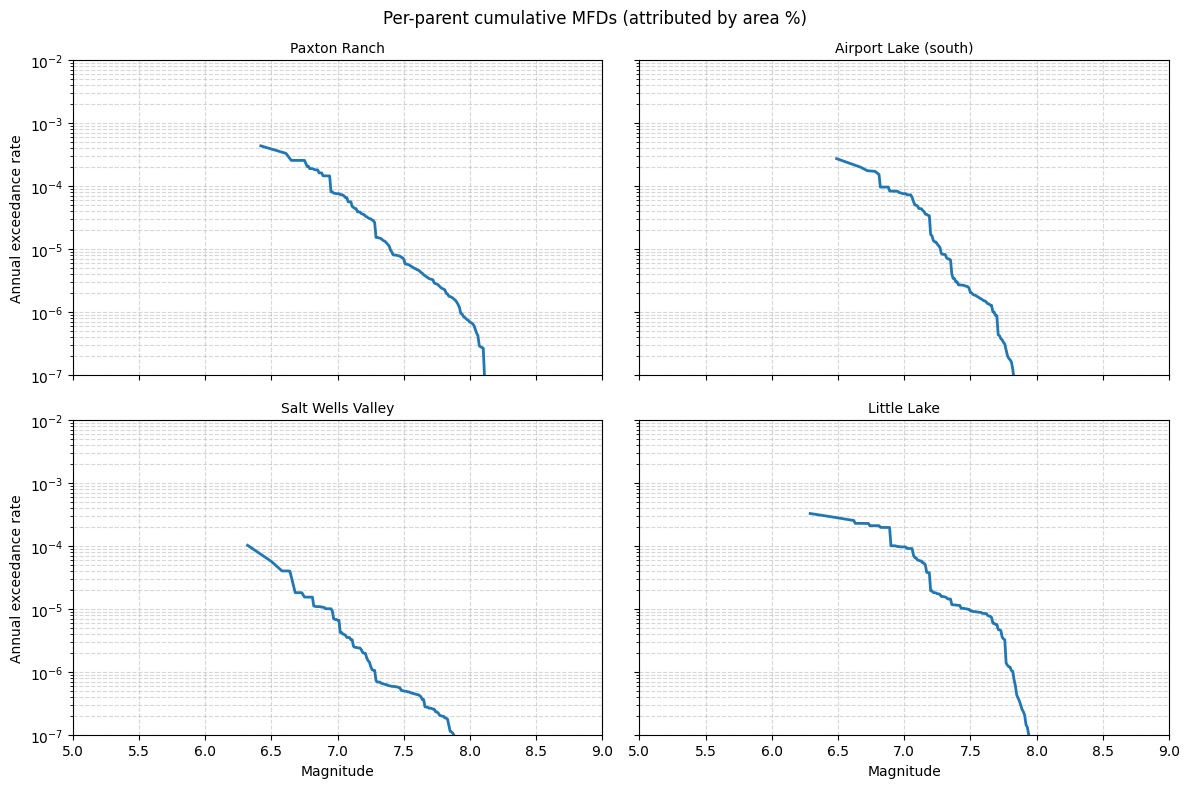

In [12]:
# Example: build per-parent magnitude-rate distributions
rups["attributed_rate"] = rups["rate"] * rups["area_pct"] / 100.0

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
example_pids = sel.parent_ids[:4]

for ax, pid in zip(axes.flat, example_pids):
    parent_rups = rups[rups["parent_id"] == pid]
    binned = parent_rups.groupby("m")["attributed_rate"].sum()
    cumulative = binned.sort_index(ascending=False).cumsum().sort_index()
    ax.semilogy(cumulative.index, cumulative.values, linewidth=2)
    ax.set_title(parents.loc[pid, "parent_name"], fontsize=10)
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.set(xlim=(5, 9), ylim=(1e-7, 1e-2))

axes[1, 0].set_xlabel("Magnitude")
axes[1, 1].set_xlabel("Magnitude")
axes[0, 0].set_ylabel("Annual exceedance rate")
axes[1, 0].set_ylabel("Annual exceedance rate")

fig.suptitle("Per-parent cumulative MFDs (attributed by area %)", fontsize=12)
plt.tight_layout()
plt.show()